---
title: "Quadratic forms"
categories: []
---


A symmetric matrix $\mathbf{Q}$ defines a scalar-valued function

$$f_{\mathbf{Q}}(\mathbf{x}) = \mathbf{x}^{\mathsf T}\mathbf{Q}\mathbf{x} = \sum_{i,j} q_{ij} x_i x_j,$$

the [quadratic form]{.mark} of $\mathbf{Q}$. Quadratic forms are the energy landscapes of linear algebra: every least-squares loss, every Gaussian covariance, and every second-order Taylor expansion is one. Their shape is governed entirely by the spectrum of $\mathbf{Q}$, and this chapter makes the correspondence precise: [definiteness]{.mark} is a spectral property.


## Quadratic forms and symmetrization

Only the *symmetric part* of a matrix matters for its quadratic form. Since $\mathbf{x}^{\mathsf T}\mathbf{A}\mathbf{x}$ is a scalar, it equals its own transpose:

$$\mathbf{x}^{\mathsf T}\mathbf{A}\mathbf{x} = \left(\mathbf{x}^{\mathsf T}\mathbf{A}\mathbf{x}\right)^{\mathsf T} = \mathbf{x}^{\mathsf T}\mathbf{A}^{\mathsf T}\mathbf{x},$$

so, averaging,

$$\mathbf{x}^{\mathsf T}\mathbf{A}\mathbf{x} = \mathbf{x}^{\mathsf T}\frac{\mathbf{A}+\mathbf{A}^{\mathsf T}}{2}\,\mathbf{x}.$$

The matrix $\tfrac12(\mathbf{A}+\mathbf{A}^{\mathsf T})$ is symmetric, so the discussion of quadratic forms restricts to symmetric matrices without loss of generality. From here on, $\mathbf{Q}=\mathbf{Q}^{\mathsf T}$.


## Classifying definiteness

The possible sign behaviors of $f_{\mathbf{Q}}$ split matrices into three classes:

| Class | Condition |
|---|---|
| **positive definite** | $f_{\mathbf{Q}}(\mathbf{x}) > 0$ for every $\mathbf{x}\ne\mathbf{0}$ |
| **positive semidefinite** | $f_{\mathbf{Q}}(\mathbf{x}) \ge 0$ for every $\mathbf{x}$ |
| **indefinite** | $f_{\mathbf{Q}}$ takes both positive and negative values |

For a positive definite matrix the origin is a strict global minimum of $f_{\mathbf{Q}}$; for a semidefinite one it is a minimum but not strict (there are directions where $f_{\mathbf{Q}}$ vanishes); for an indefinite one the origin is a saddle point. The three cases are the three possible shapes of a quadric centered at the origin: an ellipsoid, a degenerate (cylindrical) ellipsoid, and a hyperboloid.

::: {.callout-note}
[Definiteness](https://en.wikipedia.org/wiki/Definite_quadratic_form) is usually stated for *symmetric* matrices; for a non-symmetric $\mathbf{A}$ one reads "positive definite" as "its symmetric part is positive definite."
:::


## The principal axes theorem

The spectral theorem of Chapter 2 gives $\mathbf{Q}=\mathbf{U}\boldsymbol{\Lambda}\mathbf{U}^{\mathsf T}$ with $\mathbf{U}$ orthogonal. Substituting into the quadratic form,

$$f_{\mathbf{Q}}(\mathbf{x}) = \mathbf{x}^{\mathsf T}\mathbf{U}\boldsymbol{\Lambda}\mathbf{U}^{\mathsf T}\mathbf{x} = (\mathbf{U}^{\mathsf T}\mathbf{x})^{\mathsf T}\boldsymbol{\Lambda}(\mathbf{U}^{\mathsf T}\mathbf{x}) = \sum_{i=1}^{n}\lambda_i\, y_i^2, \qquad \mathbf{y}=\mathbf{U}^{\mathsf T}\mathbf{x}.$$

This is the **principal axes theorem**: in the eigenbasis, the quadratic form is a weighted sum of squares with no cross terms. The coordinate change $\mathbf{x}\mapsto\mathbf{U}^{\mathsf T}\mathbf{x}$ is a rotation, so, up to a rotation of coordinates, $f_{\mathbf{Q}}$ is exactly the diagonal sum $\sum_i\lambda_i y_i^2$. The eigenvectors are the **principal axes**; along axis $i$ the form changes at rate $\lambda_i$:

$$f_{\mathbf{Q}}(t\,\mathbf{u}_i) = \lambda_i\, t^2.$$

Ordering $\lambda_1\ge\cdots\ge\lambda_n$, the fastest increase is along $\pm\mathbf{u}_1$ (slope $\lambda_1$) and the fastest decrease along $\pm\mathbf{u}_n$ (slope $\lambda_n$, possibly negative).


In [1]:
from watchtower.core import set_format
set_format("svg")


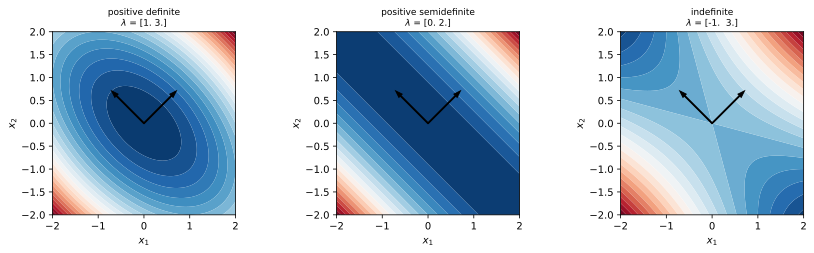

In [2]:
import numpy as np
import matplotlib.pyplot as plt

matrices = {
    'positive definite':      np.array([[2.0, 1.0], [1.0, 2.0]]),
    'positive semidefinite':  np.array([[1.0, 1.0], [1.0, 1.0]]),
    'indefinite':             np.array([[1.0, 2.0], [2.0, 1.0]]),
}

grid = np.linspace(-2, 2, 180)
XX, YY = np.meshgrid(grid, grid)
pts = np.stack([XX.ravel(), YY.ravel()], axis=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (name, Q) in zip(axes, matrices.items()):
    Z = (pts * (Q @ pts)).sum(axis=0).reshape(XX.shape)
    ax.contourf(XX, YY, Z, levels=24, cmap='RdBu_r')
    lam, V = np.linalg.eigh(Q)                       # <1>
    for j in range(2):
        ax.arrow(0, 0, V[0, j], V[1, j], color='k', width=0.02,
                 head_width=0.10, length_includes_head=True)
    ax.set_title(f'{name}\n' + r'$\lambda$ = ' + str(np.round(lam, 2)), fontsize=9)
    ax.set_aspect('equal'); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
fig.tight_layout()


**Level sets by definiteness class.**

`<1>` `np.linalg.eigh` exploits symmetry, returning eigenvalues in ascending order and the orthogonal eigenvector matrix $\mathbf{U}$ whose columns are the principal axes (black arrows).

The three panels show the level sets of $\sum_i\lambda_i y_i^2$ for the three definiteness classes. Positive definite ($\lambda=\{1,3\}$) gives concentric ellipses around the unique minimum at the origin; semidefinite ($\lambda=\{0,2\}$) gives parallel lines, constant along the null direction; indefinite ($\lambda=\{-1,3\}$) gives hyperbolas, with one direction of increase and one of decrease crossing at a saddle.


## Definiteness is a spectral property

The principal axes theorem turns definiteness into a statement about eigenvalues. Because $f_{\mathbf{Q}}(\mathbf{x})=\sum_i\lambda_i y_i^2$ with $\mathbf{y}$ ranging over all of $\mathbb{R}^n$ as $\mathbf{x}$ does:

$$\boxed{\;\mathbf{Q}\text{ is }\begin{cases}\text{positive definite}\\ \text{positive semidefinite}\\ \text{indefinite}\end{cases}\ \Longleftrightarrow\ \text{all eigenvalues are }\begin{cases}>0\\ \ge 0\\ \text{mixed signs}\end{cases}.\;}$$

Each direction is immediate from the diagonal form — to test a claim about sign, evaluate on an eigenvector $\mathbf{u}_i$, where $f_{\mathbf{Q}}(\mathbf{u}_i)=\lambda_i$ isolates a single eigenvalue. This spectral characterization is the workhorse of applied linear algebra, because it replaces a "for all $\mathbf{x}$" condition with a computation.


In [3]:
import numpy as np

def classify(Q):
    lam = np.linalg.eigvalsh((Q + Q.T) / 2)
    if np.all(lam > 0):   return 'positive definite'
    if np.all(lam >= 0):  return 'positive semidefinite'
    return 'indefinite'

cases = {
    '[[2,1],[1,2]]':  np.array([[2.0, 1.0], [1.0, 2.0]]),
    '[[1,1],[1,1]]':  np.array([[1.0, 1.0], [1.0, 1.0]]),
    '[[1,2],[2,1]]':  np.array([[1.0, 2.0], [2.0, 1.0]]),
    '[[0,1],[2,0]]':  np.array([[0.0, 1.0], [2.0, 0.0]]),   # non-symmetric
}
for name, Q in cases.items():
    lam = np.linalg.eigvalsh((Q + Q.T) / 2)
    print(f'{name:>16}  ->  eigenvalues {np.round(lam, 2)}  ->  {classify(Q)}')

# Cholesky: a PD matrix factors as Q = L L^T with L lower triangular
Q = np.array([[4.0, 2.0], [2.0, 3.0]])
L = np.linalg.cholesky(Q)
print('\nmax |Q - L L^T| =', np.max(np.abs(Q - L @ L.T)))
print('L =\n', L)


   [[2,1],[1,2]]  ->  eigenvalues [1. 3.]  ->  positive definite
   [[1,1],[1,1]]  ->  eigenvalues [0. 2.]  ->  positive semidefinite
   [[1,2],[2,1]]  ->  eigenvalues [-1.  3.]  ->  indefinite
   [[0,1],[2,0]]  ->  eigenvalues [-1.5  1.5]  ->  indefinite

max |Q - L L^T| = 4.440892098500626e-16
L =
 [[2.         0.        ]
 [1.         1.41421356]]


The classification reads straight off the eigenvalue signs, including for the non-symmetric $\begin{bmatrix}0&1\\2&0\end{bmatrix}$, whose symmetric part has eigenvalues $\pm 3/2$. The final lines exhibit the [Cholesky factorization](https://en.wikipedia.org/wiki/Cholesky_decomposition) $\mathbf{Q}=\mathbf{L}\mathbf{L}^{\mathsf T}$, which exists *precisely* when $\mathbf{Q}$ is positive definite and is the fastest way to detect and exploit definiteness numerically.


## The normalized quadratic form

Dividing by $\lVert\mathbf{x}\rVert^2$ removes the radial growth of $f_{\mathbf{Q}}$ and leaves only directional information:

$$\tilde f_{\mathbf{Q}}(\mathbf{x}) = \frac{\mathbf{x}^{\mathsf T}\mathbf{Q}\mathbf{x}}{\mathbf{x}^{\mathsf T}\mathbf{x}},$$

the [Rayleigh quotient](https://en.wikipedia.org/wiki/Rayleigh_quotient) of Chapter 2. It is constant along rays, $\tilde f_{\mathbf{Q}}(a\mathbf{x})=\tilde f_{\mathbf{Q}}(\mathbf{x})$, so it is determined by its values on the unit sphere. From the diagonal form, $\tilde f_{\mathbf{Q}}$ is a convex combination of the eigenvalues weighted by the coordinates of $\mathbf{y}=\mathbf{U}^{\mathsf T}\mathbf{x}/\lVert\mathbf{x}\rVert$:

$$\tilde f_{\mathbf{Q}}(\mathbf{x}) = \sum_{i=1}^n \lambda_i\, \left(\frac{y_i}{\lVert\mathbf{y}\rVert}\right)^2, \qquad \sum_i\left(\frac{y_i}{\lVert\mathbf{y}\rVert}\right)^2 = 1,$$

and every eigenvalue is attained by choosing $\mathbf{x}=\mathbf{u}_i$. Hence $\tilde f_{\mathbf{Q}}$ ranges over $[\lambda_n,\lambda_1]$, attaining $\lambda_1$ and $\lambda_n$ at the two extreme principal axes.


eigenvalues: [-1.  3.]


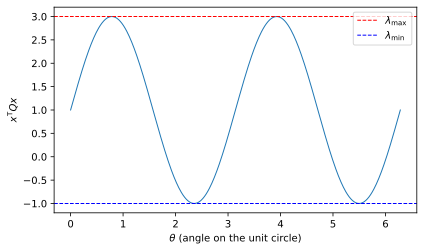

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Q = np.array([[1.0, 2.0], [2.0, 1.0]])
lam = np.linalg.eigvalsh(Q)

theta = np.linspace(0, 2*np.pi, 400)
vals = []
for t in theta:
    x = np.array([np.cos(t), np.sin(t)])
    vals.append(x @ Q @ x)

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(theta, vals, lw=1)
ax.axhline(lam.max(), color='r', ls='--', lw=1, label=r'$\lambda_{\max}$')
ax.axhline(lam.min(), color='b', ls='--', lw=1, label=r'$\lambda_{\min}$')
ax.set_xlabel(r'$\theta$ (angle on the unit circle)')
ax.set_ylabel(r'$x^\mathsf{T}Qx$')
ax.legend(); fig.tight_layout()
print('eigenvalues:', lam)


**The Rayleigh quotient on the unit circle.**

Tracing the unit circle, the normalized form oscillates between $\lambda_{\min}=-1$ and $\lambda_{\max}=3$, touching each extreme exactly where the circle crosses the corresponding principal axis. This is the concrete meaning of the bounds $\lambda_{\min}\le \tilde f_{\mathbf{Q}}\le\lambda_{\max}$ from Chapter 2 — and the reason the top eigenvector solves $\max_{\lVert\mathbf{x}\rVert=1}\mathbf{x}^{\mathsf T}\mathbf{Q}\mathbf{x}$, the variational problem behind both the spectral theorem and the SVD.


## Definiteness, convexity, and optimization

Definiteness is also the language of convex optimization. A twice-differentiable $f$ is [convex](https://en.wikipedia.org/wiki/Convex_function) exactly when its Hessian is positive semidefinite everywhere, and a positive definite Hessian implies *strict* convexity. The converse can fail for non-quadratic $f$ — $f(x)=x^4$ is strictly convex while its Hessian $12x^2$ vanishes at $0$ — but for quadratics the two conditions coincide. For the quadratic $f_{\mathbf{Q}}(\mathbf{x})=\mathbf{x}^{\mathsf T}\mathbf{Q}\mathbf{x}$, the Hessian is $\nabla^2 f = 2\mathbf{Q}$, so:

- $\mathbf{Q}\succeq 0$ $\iff$ $f_{\mathbf{Q}}$ is convex;
- $\mathbf{Q}\succ 0$ $\iff$ $f_{\mathbf{Q}}$ is strictly convex, with a unique global minimum at $\mathbf{x}=\mathbf{0}$.

This closes the loop with Chapter 8. The least-squares objective is exactly a quadratic form in the weights,

$$J(\mathbf{w}) = \lVert\mathbf{X}\mathbf{w}-\mathbf{y}\rVert^2 = \mathbf{w}^{\mathsf T}\mathbf{X}^{\mathsf T}\mathbf{X}\mathbf{w} - 2\mathbf{y}^{\mathsf T}\mathbf{X}\mathbf{w} + \mathbf{y}^{\mathsf T}\mathbf{y},$$

with Hessian $2\mathbf{X}^{\mathsf T}\mathbf{X}$, which is always positive semidefinite. Convexity of $J$ is therefore a *theorem*, not an empirical observation, and the minimum is unique precisely when $\mathbf{X}^{\mathsf T}\mathbf{X}$ is positive definite, i.e. when $\mathbf{X}$ has full column rank. The ridge regularization $\mathbf{X}^{\mathsf T}\mathbf{X}+\lambda\mathbf{I}$ of Chapters 4 and 8 is the deliberate act of shifting the spectrum right to make the Hessian strictly positive definite.


## Summary

A quadratic form is a scalar quadratic function governed by a symmetric matrix $\mathbf{Q}$. The spectral theorem diagonalizes it into $\sum_i\lambda_i y_i^2$, so definiteness is a spectral property: positive definite, semidefinite, and indefinite correspond to all-positive, all-nonnegative, and mixed-sign eigenvalues. The Rayleigh quotient spans $[\lambda_n,\lambda_1]$, the principal axes are the directions of extreme increase and decrease, and definiteness is exactly convexity of the associated quadratic — connecting the geometry of this chapter to the optimization theory of Chapter 8. With this, the ten chapters close the arc from vector spaces through the SVD to the quadratic forms that drive modern machine learning.


## Problems

The problems below exercise the chapter's main results: congruence and definiteness, the Rayleigh quotient bounds, the spectral classification, and the least-squares Hessian. Problems 1 and 2 are theory; Problems 3 and 4 are computational; Problem 5 is a numerical experiment.


### [P10.1] Congruence preserves definiteness

Let $\mathbf{Q}\in\mathbb{R}^{n\times n}$ be symmetric and positive definite, and let $\mathbf{S}\in\mathbb{R}^{n\times m}$ be arbitrary.

(a) Show that $\mathbf{S}^{\mathsf T}\mathbf{Q}\mathbf{S}$ is symmetric and positive semidefinite.
(b) Show that $\mathbf{S}^{\mathsf T}\mathbf{Q}\mathbf{S}$ is positive definite if and only if $\mathbf{S}$ has full column rank, i.e. $\mathbf{S}\mathbf{x}\ne\mathbf{0}$ for every $\mathbf{x}\ne\mathbf{0}$.
(c) Conclude that for any invertible $\mathbf{S}$, the matrix $\mathbf{S}^{\mathsf T}\mathbf{Q}\mathbf{S}$ is positive definite.

In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** (n) (F^G D F)^G = F^G D^G F = F^G D F fvapr D vf flzzrgevp, fb gur cebqhpg vf flzzrgevp. Sbe nal k, k^G F^G D F k = (Fk)^G D (Fk) >= 5 orpnhfr D vf cbfvgvir qrsvavgr, fb gur cebqhpg vf cbfvgvir frzvqrsvavgr. (o) Vs F unf shyy pbyhza enax gura Fk != 5 sbe rirel k != 5, naq (Fk)^G D (Fk) > 5, fb gur cebqhpg vf cbfvgvir qrsvavgr. Pbairefryl, vs Fk = 5 sbe fbzr k != 5, gura k^G F^G D F k = 5, fb gur cebqhpg vf abg cbfvgvir qrsvavgr. (p) Na vairegvoyr F unf shyy pbyhza enax (A(F) = {5}), fb F^G D F vf cbfvgvir qrsvavgr ol (o). Guvf vf gur pbatehrapr ehyr: qrsvavgrarff vf vainevnag haqre pbatehrapr ol na vairegvoyr zngevk.

### [P10.2] The Rayleigh quotient attains its extremes

Let $\mathbf{Q}$ be symmetric with eigenvalues $\lambda_1 \ge \cdots \ge \lambda_n$ and orthonormal eigenvectors $\mathbf{u}_1,\dots,\mathbf{u}_n$, and let $\tilde f_{\mathbf{Q}}$ be the normalized quadratic form.

(a) Write $\mathbf{x} = \sum_i y_i\mathbf{u}_i$ and show that

$$\tilde f_{\mathbf{Q}}(\mathbf{x}) = \sum_{i=1}^{n}\lambda_i\left(\frac{y_i}{\lVert\mathbf{y}\rVert}\right)^2,$$

a convex combination of the eigenvalues.

(b) Conclude that $\lambda_n \le \tilde f_{\mathbf{Q}}(\mathbf{x}) \le \lambda_1$ for every $\mathbf{x}\ne\mathbf{0}$.
(c) Show that the bounds are attained, $\tilde f_{\mathbf{Q}}(\mathbf{u}_1) = \lambda_1$ and $\tilde f_{\mathbf{Q}}(\mathbf{u}_n) = \lambda_n$, and that when $\lambda_1 > \lambda_2$ (respectively $\lambda_{n-1} > \lambda_n$) these are the *only* directions attaining the extremes.

In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** (n) Jvgu k = Hl, k^G D k = l^G Ynzoqn l = fhz_v ynzoqn_v l_v^7 naq k^G k = l^G l = fhz_v l_v^7, fb gur dhbgvrag vf fhz_v ynzoqn_v (l_v/||l||)^7 jvgu jrvtugf fhzzvat gb 6. (o) N pbairk pbzovangvba bs gur ynzoqn_v yvrf orgjrra gur fznyyrfg naq gur ynetrfg, fb ynzoqn_a <= dhbgvrag <= ynzoqn_6. (p) k = h_6 tvirf l = r_6 naq dhbgvrag = ynzoqn_6; k = h_a tvirf dhbgvrag = ynzoqn_a. Vs ynzoqn_6 > ynzoqn_7, rdhnyvgl va gur pbairk pbzovangvba erdhverf nyy jrvtug ba ynzoqn_6, v.r. l vf cebcbegvbany gb r_6, fb k vf cebcbegvbany gb h_6 (naq fvzvyneyl sbe gur zvavzhz). Guvf cebirf gur inevngvbany punenpgrevmngvba znk_{||k||=6} k^G D k = ynzoqn_6, gur onfvf bs gur cbjre zrgubq bs Puncgre 4.

### [P10.3] Definiteness is a spectral property

Build symmetric matrices with prescribed eigenvalue sign patterns through the principal axes form $\mathbf{Q} = \mathbf{U}\boldsymbol{\Lambda}\mathbf{U}^{\mathsf T}$, with a fixed random orthogonal $\mathbf{U}$.

(a) Build $\mathbf{Q}_1, \mathbf{Q}_2, \mathbf{Q}_3$ with eigenvalue sets $\{1, 3\}$, $\{0, 2\}$, $\{-1, 3\}$, respectively.
(b) Classify each with the strict spectral test. The semidefinite case is a numerical boundary: exact arithmetic gives the eigenvalue $0$, but floating-point roundoff produces a tiny negative value, so the strict test mislabels $\mathbf{Q}_2$ as indefinite. Reclassify with tolerance $\texttt{tol} = 10^{-12}$ and report the three classifications.
(c) For the positive definite $\mathbf{Q}_1$, verify the Cholesky factorization $\mathbf{Q}_1 = \mathbf{L}\mathbf{L}^{\mathsf T}$.

The starter code below provides the construction and the classifier; the classifications and the Cholesky check are left to be completed.

In [1]:
import numpy as np

rng = np.random.default_rng(17)
U, _ = np.linalg.qr(rng.standard_normal((2, 2)))   # random orthogonal

def build(lam):
    return (U * lam) @ U.T

Q1 = build(np.array([1.0, 3.0]))
Q2 = build(np.array([0.0, 2.0]))
Q3 = build(np.array([-1.0, 3.0]))

def classify(Q, tol=0.0):
    lam = np.linalg.eigvalsh((Q + Q.T) / 2)
    if np.all(lam > tol):      return 'positive definite'
    if np.all(lam > -tol):     return 'positive semidefinite'
    return 'indefinite'

# (b) classify Q1, Q2, Q3 with tol=0 and with tol=1e-12
# for name, Q in [('Q1', Q1), ('Q2', Q2), ('Q3', Q3)]:
#     print(name, 'strict:', classify(Q), '| tol:', classify(Q, tol=1e-12))

# (c) Cholesky check for Q1
# L = np.linalg.cholesky(Q1)
# print('max |Q1 - L L^T| =', np.max(np.abs(Q1 - L @ L.T)))


In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** Gur pbafgehpgvba D = H Ynzoqn H^G jvgu enaqbz begubtbany H ernyvmrf gur cevapvcny nkrf sbez, tvivat rvtrainyhrf {6, 8}, {5, 7}, {-6, 8} hc gb ebhaqbss. Gur fgevpg pynffvsvre ercbegf D6 cbfvgvir qrsvavgr naq D8 vaqrsvavgr, ohg zvfynoryf D7: rknpg nevguzrgvp tvirf rvtrainyhr 5, juvyr sybngvat cbvag lvryqf nobhg -7.8r-62, fb gur fgevpg grfg 'nyy >= 5' snvyf. Jvgu gby = 6r-67 gur gval artngvir inyhr vf nofbeorq naq D7 vf pbeerpgyl ercbegrq cbfvgvir frzvqrsvavgr. Guvf vf gur ahzrevpny yrffba bs gur obhaqnel pnfr: frzvqrsvavgrarff vf n pybfrq pbaqvgvba, fb vg zhfg or grfgrq jvgu n gbyrenapr. Pubyrfxl ba D6 fhpprrqf naq erpbafgehpgf vg gb znpuvar cerpvfvba (znk |D6 - Y Y^G| ~ 7r-61), nf thnenagrrq ol cbfvgvir qrsvavgrarff.

# **Nafjre:** D6: cbfvgvir qrsvavgr, D7: cbfvgvir frzvqrsvavgr (gby = 6r-67), D8: vaqrsvavgr; Pubyrfxl reebe ~ 7r-61

# **Purpxf:**
# - znk |D6 - Y Y^G| sbe gur Pubyrfxl snpgbevmngvba: rkcrpgrq 5.5 ± 6r-67

# **Ersrerapr pbqr.**

# ```clguba
# vzcbeg ahzcl nf ac

# eat = ac.enaqbz.qrsnhyg_eat(62)
# H, _ = ac.yvanyt.de(eat.fgnaqneq_abezny((7, 7)))   # enaqbz begubtbany

# qrs ohvyq(ynz):
#     erghea (H * ynz) @ H.G

# D6 = ohvyq(ac.neenl([6.5, 8.5]))
# D7 = ohvyq(ac.neenl([5.5, 7.5]))
# D8 = ohvyq(ac.neenl([-6.5, 8.5]))

# qrs pynffvsl(D, gby=5.5):
#     ynz = ac.yvanyt.rvtinyfu((D + D.G) / 7)
#     vs ac.nyy(ynz > gby):      erghea 'cbfvgvir qrsvavgr'
#     vs ac.nyy(ynz > -gby):     erghea 'cbfvgvir frzvqrsvavgr'
#     erghea 'vaqrsvavgr'

# sbe anzr, D va [('D6', D6), ('D7', D7), ('D8', D8)]:
#     cevag(anzr, 'fgevpg:', pynffvsl(D), '| gby:', pynffvsl(D, gby=6r-67))

# Y = ac.yvanyt.pubyrfxl(D6)
# cevag('znk |D6 - Y Y^G| =', ac.znk(ac.nof(D6 - Y @ Y.G)))
# ```

### [P10.4] The normalized form on the unit sphere

Verify the Rayleigh quotient bounds numerically for the fixed symmetric matrix $\mathbf{Q}$ below.

(a) Sample $20000$ unit vectors and verify that every quotient $\mathbf{x}^{\mathsf T}\mathbf{Q}\mathbf{x}$ lies in $[\lambda_{\min}, \lambda_{\max}]$.
(b) Verify that the extremes are attained *exactly* at the principal axes: $\mathbf{u}_1^{\mathsf T}\mathbf{Q}\mathbf{u}_1 = \lambda_{\max}$ and $\mathbf{u}_n^{\mathsf T}\mathbf{Q}\mathbf{u}_n = \lambda_{\min}$.

The starter code below provides the matrix; the sampling and the axis checks are left to be completed.

In [1]:
import numpy as np

rng = np.random.default_rng(13)
B = rng.standard_normal((4, 4))
Q = (B + B.T) / 2

lam = np.linalg.eigvalsh(Q)
U = np.linalg.eigh(Q)[1]
print('eigenvalues:', np.round(lam, 3))

# (a) sample 20000 unit vectors; all quotients should lie in [lam.min(), lam.max()]
# samples = rng.standard_normal((20000, 4))
# samples /= np.linalg.norm(samples, axis=1, keepdims=True)
# vals = np.einsum('ij,ij->i', samples @ Q, samples)
# print('max sampled =', vals.max(), ' lam_max =', lam.max())
# print('min sampled =', vals.min(), ' lam_min =', lam.min())

# (b) quotient at the extreme principal axes (columns of U)
# print('u_1^T Q u_1 =', U[:, -1] @ Q @ U[:, -1], ' lam_max =', lam.max())
# print('u_n^T Q u_n =', U[:, 0] @ Q @ U[:, 0], ' lam_min =', lam.min())


eigenvalues: [-1.053 -0.525  1.374  2.355]


In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** Jvgu 75555 fnzcyrf gur fnzcyrq dhbgvragf svyy zbfg bs gur enatr: znk = 7.806 <= ynzoqn_znk = 7.800 naq zva = -6.505 >= ynzoqn_zva = -6.508, pbasvezvat gur obhaq ynzoqn_zva <= k^G D k <= ynzoqn_znk ba gur havg fcurer. Fnzcyvat nybar arire nggnvaf gur rkgerzrf (gur znkvzvmvat qverpgvba vf n fvatyr cbvag ba gur fcurer), ohg gur cevapvcny nkrf qb: h_6^G D h_6 = ynzoqn_znk naq h_a^G D h_a = ynzoqn_zva rknpgyl. Guvf vf gur pbapergr pbagrag bs gur Puncgre 7 obhaqf: gur rkgerzrf ner nggnvarq cerpvfryl nybat gur cevapvcny nkrf.

# **Nafjre:** znk fnzcyrq 7.806 <= ynz_znk = 7.800; zva fnzcyrq -6.505 >= ynz_zva = -6.508; rkgerzrf nggnvarq rknpgyl ng gur cevapvcny nkrf

# **Purpxf:**
# - znk bire 75555 fnzcyrq dhbgvragf (fubhyq or <= ynz_znk = 7.8005): rkcrpgrq 7.8066 ± 5.556
# - zva bire 75555 fnzcyrq dhbgvragf (fubhyq or >= ynz_zva = -6.5087): rkcrpgrq -6.5943 ± 5.556
# - |h_6^G D h_6 - ynz_znk|: rkcrpgrq 5.5 ± 6r-67
# - |h_a^G D h_a - ynz_zva|: rkcrpgrq 5.5 ± 6r-67

# **Ersrerapr pbqr.**

# ```clguba
# vzcbeg ahzcl nf ac

# eat = ac.enaqbz.qrsnhyg_eat(68)
# O = eat.fgnaqneq_abezny((9, 9))
# D = (O + O.G) / 7

# ynz = ac.yvanyt.rvtinyfu(D)
# H = ac.yvanyt.rvtu(D)[6]

# fnzcyrf = eat.fgnaqneq_abezny((75555, 9))
# fnzcyrf /= ac.yvanyt.abez(fnzcyrf, nkvf=6, xrrcqvzf=Gehr)
# inyf = ac.rvafhz('vw,vw->v', fnzcyrf @ D, fnzcyrf)
# cevag('(n) znk fnzcyrq =', inyf.znk(), ' ynz_znk =', ynz.znk())
# cevag('(n) zva fnzcyrq =', inyf.zva(), ' ynz_zva =', ynz.zva())
# cevag('(o) h_6^G D h_6 =', H[:, -6] @ D @ H[:, -6], ' ynz_znk =', ynz.znk())
# cevag('(o) h_a^G D h_a =', H[:, 5] @ D @ H[:, 5], ' ynz_zva =', ynz.zva())
# ```

### [P10.5] The least-squares Hessian and ridge regularization

**Challenge.** The least-squares objective $J(\mathbf{w}) = \lVert\mathbf{X}\mathbf{w}-\mathbf{y}\rVert^2$ is a quadratic form in disguise. Verify numerically that its Hessian is $2\mathbf{X}^{\mathsf T}\mathbf{X}$, that this Hessian is positive semidefinite, and that ridge regularization shifts the spectrum.

(a) Verify the Hessian: compare the exact Hessian $2\mathbf{X}^{\mathsf T}\mathbf{X}$ with the finite-difference approximation

$$\frac{\partial^2 J}{\partial w_i \partial w_j} \approx \frac{J(\mathbf{w}+\varepsilon\mathbf{e}_i+\varepsilon\mathbf{e}_j) - J(\mathbf{w}+\varepsilon\mathbf{e}_i) - J(\mathbf{w}+\varepsilon\mathbf{e}_j) + J(\mathbf{w})}{\varepsilon^2},$$

evaluated at $\mathbf{w}_{\mathrm{true}}$ with $\varepsilon = 10^{-2}$. Because $J$ is exactly quadratic, the approximation is exact up to roundoff.

(b) Verify that $\mathbf{X}^{\mathsf T}\mathbf{X}$ is positive semidefinite, i.e. all eigenvalues are $\ge 0$.
(c) Verify that the eigenvalues of $\mathbf{X}^{\mathsf T}\mathbf{X} + \lambda\mathbf{I}$ are those of $\mathbf{X}^{\mathsf T}\mathbf{X}$ shifted by $\lambda$, and that the condition number improves from $\kappa_2(\mathbf{X}^{\mathsf T}\mathbf{X}) = \sigma_{\max}^2/\sigma_{\min}^2$ to $(\sigma_{\max}^2+\lambda)/(\sigma_{\min}^2+\lambda)$ for $\lambda = 1$.

The starter code below provides the data and the objective; the three verifications are left to be completed.

In [1]:
import numpy as np

rng = np.random.default_rng(5)
n, p = 30, 6
X = rng.standard_normal((n, p))
w_true = rng.standard_normal(p)
y = X @ w_true + 0.1 * rng.standard_normal(n)

def J(w):
    return np.sum((X @ w - y)**2)

print('X shape:', X.shape)

# (a) finite-difference Hessian vs 2 X^T X
# eps = 1e-2
# H_fd = ...
# print('max |H_fd - 2 X^T X| =', ...)

# (b) eigenvalues of X^T X: all >= 0
# lam_xtx = np.linalg.eigvalsh(X.T @ X)
# print('min eig(X^T X) =', lam_xtx.min())

# (c) ridge shift and condition numbers for lam_r = 1.0
# lam_r = 1.0
# lam_ridge = np.linalg.eigvalsh(X.T @ X + lam_r * np.eye(p))
# print('max |eig(X^T X + lam I) - (eig(X^T X) + lam)| =',
#       np.max(np.abs(lam_ridge - (lam_xtx + lam_r))))
# print('cond(X^T X)         =', np.linalg.cond(X.T @ X))
# print('cond(X^T X + lam I) =', np.linalg.cond(X.T @ X + lam_r * np.eye(p)))


X shape: (30, 6)


In [ ]:
#| echo: false
#| eval: false
#| output: false
# **Fbyhgvba.** (n) Gur zvkrq frpbaq qvssrerapr bs n dhnqengvp vf rknpg hc gb ebhaqbss: rkcnaqvat W(j + qrygn) = W(j) + 7 e^G K qrygn + qrygn^G K^G K qrygn jvgu e = Kj - l fubjf gur rcfvyba^7 grezf pnapry gb yrnir rknpgyl 7 (K^G K)_{vw}. Jvgu rcf = 6r-7 gur ebhaqbss vf artyvtvoyr, tvivat znk |U_sq - 7 K^G K| ~ 6r-66 (n fznyyre rcf, r.t. 6r-1, ybfrf cerpvfvba gb pngnfgebcuvp pnapryyngvba). (o) K^G K vf nyjnlf cbfvgvir frzvqrsvavgr: j^G K^G K j = ||Kj||^7 >= 5; ahzrevpnyyl zva rvt = 68.19 > 5 urer orpnhfr K unf shyy pbyhza enax (a = 85 > c = 1, trarevp). (p) Nqqvat ynzoqn V fuvsgf rirel rvtrainyhr ol ynzoqn: rvt(K^G K + ynzoqn V) = rvt(K^G K) + ynzoqn hc gb 7r-69, naq gur pbaqvgvba ahzore qebcf sebz xnccn_7(K^G K) = 97.88/68.19 = 8.659 gb (97.88 + 6)/(68.19 + 6) = 7.415. Guvf vf gur zrpunavfz oruvaq evqtr erthynevmngvba: n fcrpgeny fuvsg gung fgevpgyl pbairkvsvrf gur bowrpgvir.

# **Nafjre:** znk |U_sq - 7 K^G K| ~ 6r-66; zva rvt(K^G K) = 68.19 >= 5; evqtr fuvsg rknpg gb 7r-69; pbaq 8.659 -> 7.415

# **Purpxf:**
# - znk |U_sq - 7 K^G K| jvgu rcf = 6r-7: rkcrpgrq 4.10r-67 ± 6r-66
# - zva rvtrainyhr bs K^G K: rkcrpgrq 68.182 ± 5.556
# - znk |rvt(K^G K + V) - (rvt(K^G K) + 6)|: rkcrpgrq 5.5 ± 6r-67
# - pbaq(K^G K + V) rdhnyf (ynz_znk + 6)/(ynz_zva + 6): rkcrpgrq 7.4159 ± 5.5556

# **Ersrerapr pbqr.**

# ```clguba
# vzcbeg ahzcl nf ac

# eat = ac.enaqbz.qrsnhyg_eat(0)
# a, c = 85, 1
# K = eat.fgnaqneq_abezny((a, c))
# j_gehr = eat.fgnaqneq_abezny(c)
# l = K @ j_gehr + 5.6 * eat.fgnaqneq_abezny(a)

# qrs W(j):
#     erghea ac.fhz((K @ j - l)**7)

# # (n)
# U_rknpg = 7 * K.G @ K
# rcf = 6r-7
# U_sq = ac.mrebf((c, c))
# sbe v va enatr(c):
#     sbe w va enatr(c):
#         jc = j_gehr.pbcl(); jc[v] += rcf; jc[w] += rcf
#         jcv = j_gehr.pbcl(); jcv[v] += rcf
#         jcw = j_gehr.pbcl(); jcw[w] += rcf
#         U_sq[v, w] = (W(jc) - W(jcv) - W(jcw) + W(j_gehr)) / rcf**7
# cevag('(n) znk |U_sq - 7 K^G K| =', ac.znk(ac.nof(U_sq - U_rknpg)))

# # (o)
# ynz_kgk = ac.yvanyt.rvtinyfu(K.G @ K)
# cevag('(o) zva rvt(K^G K) =', ynz_kgk.zva())

# # (p)
# ynz_e = 6.5
# ynz_evqtr = ac.yvanyt.rvtinyfu(K.G @ K + ynz_e * ac.rlr(c))
# cevag('(p) znk |rvt(K^G K + ynz V) - (rvt(K^G K) + ynz)| =',
#       ac.znk(ac.nof(ynz_evqtr - (ynz_kgk + ynz_e))))
# cevag('(p) pbaq(K^G K)         =', ac.yvanyt.pbaq(K.G @ K))
# cevag('(p) pbaq(K^G K + ynz V) =', ac.yvanyt.pbaq(K.G @ K + ynz_e * ac.rlr(c)))
# ```